In [1]:
import wrf
from wrf import CoordPair

import cartopy.crs as ccrs
from cartopy import geodesic
from cartopy.feature import NaturalEarthFeature, BORDERS, ShapelyFeature, OCEAN, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shpreader

import netCDF4 as nc
import glob
import numpy as np
import xarray as xr
import datetime as dt
import os
import pandas as pd
import warnings
import pickle

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
from matplotlib.patches import Rectangle
from matplotlib import colors

from metpy.interpolate import cross_section
import pyart
import pyproj
import seaborn as sns

import shapely
from shapely.geometry.polygon import Polygon
from copy import deepcopy

warnings.simplefilter("ignore")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [3]:
# General info
path_save = "/g/data/up6/ai2733/WRF_cases/"
path_figs = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"

lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}

In [4]:
def latlon_dist(lat, lon, lats, lons):
    """""""""""""""""""""""""""""""""""""""""""""""""""
    #Calculate great circle distance (Harversine) between a lat lon point (lat, lon) and a list of lat lon
    # points (lats, lons)
    """""""""""""""""""""""""""""""""""""""""""""""""""
    R = 6373.0

    lat1 = np.deg2rad(lat)
    lon1 = np.deg2rad(lon)
    lat2 = np.deg2rad(lats)
    lon2 = np.deg2rad(lons)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return (R * c)
    
def plot_time(idx, xr_plot, ax=None, r=50, extent=[], lats_cross=[], lons_cross=[], coords_max=[], plot_aws=True,
              save_fig=False, name_fig=False, plot_winds = False, u = False, v= False, sep_w = False, scale_w = False,  **kwargs):

    """""""""""""""""""""""""""""""""""""""""""""""""""
    Function to plot WRF variable at certain time
    """""""""""""""""""""""""""""""""""""""""""""""""""
    
    # Plot var
    im = xr_plot.plot(ax=ax, x="XLONG", y="XLAT", **kwargs)

    if plot_aws:
        lat_aws, lon_aws = lat_lon_cases[case]
        circle_points = geodesic.Geodesic().circle(lon_aws, lat_aws, r*1000)
        geom = shapely.geometry.Polygon(circle_points)
        ax.scatter(lon_aws, lat_aws, marker="x", facecolor="red", linewidths=1.0, s=30.)
        ax.add_geometries((geom,), crs=ccrs.PlateCarree(), facecolor='none', edgecolor="red", linewidth=1.0, linestyle="--")

    if len(coords_max) == 2:
        ax.scatter(coords_max[0], coords_max[1], marker="x", facecolor="magenta", linewidths=3.0, s=100.)

    if len(lats_cross) == 2:
        ax.plot(lons_cross, lats_cross, color="black", ls="--")

    if plot_winds:
        q=xr.Dataset({"u":u,"v":v}).coarsen(dim={"south_north":sep_w,"west_east":sep_w},boundary="trim").mean().plot.quiver("XLONG","XLAT","u","v",ax=ax,scale=scale_w, add_guide = False)  
        ax.quiverkey(q, 0.1, 1.02, 10, '10 m/s', labelpos='E', coordinates='axes', fontproperties={'size': 13})

    ax.coastlines()
    if len(extent) > 0:
        ax.set_extent(extent)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), x_inline=False, y_inline=False,
                      draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    # Only show left labels for left column
    gl.left_labels = idx % 2 == 0
    gl.right_labels = False

    # Only show bottom labels for bottom row
    gl.bottom_labels = idx >= 2
    gl.top_labels = False
    
    try:
        ax.set_title(str(ax.title).split("Time = ")[1][:-5].replace("T", ' '), size=16)
    except:
        pass
    ax.set_title("")
    
    return im


In [7]:
# To read fewer files
dates_filter_cases = {"CASE1":{"d03":("2015-12-16_07:05:00", "2015-12-16_08:35:00")},
                    "CASE2_new":{"d03":("2009-01-20_04:05:00", "2009-01-20_06:05:00")}, 
                    "CASE3_new":{"d03":("2017-02-17_07:05:00", "2017-02-17_08:35:00")}}

In [8]:
def get_data_cross_section(case):
        
    """""""""""""""""""""""""""""""""""""""""""""""""""
    Get all data needed to run the cross section plots for certain case
    """""""""""""""""""""""""""""""""""""""""""""""""""
    
    def find_idx_file(dom, date_i, date_f): # Dates have to be exact
        """
        # Find the indexes of the files between dates: to save memory when reading the files
        """
        list_files = np.sort(glob.glob(f"{path_wrf}wrfout_{dom}_*"))
        idx_ti = list(list_files).index(f'{path_wrf}wrfout_{dom}_{date_i}') 
        try:
            idx_tf = list(list_files).index(f'{path_wrf}wrfout_{dom}_{date_f}') 
        except: 
            idx_tf = -1
        return (int(idx_ti), int(idx_tf))
    
    def get_index_file(dom, time_):
        """
        # Get File that contain date of interest
        """
        list_files = np.sort(glob.glob(f"{path_wrf}wrfout_{dom}_*"))
        list_times = [dt.datetime.strptime(f.split(f"wrfout_{dom}_")[-1], "%Y-%m-%d_%H:%M:%S") for f in list_files]
        aux = [time_ > l for l in list_times]
        idx_1 = np.where(aux)[0][-1]
        print (idx_1)
        # In file, get index of date
        idx_2 = list(np.array(wrf.g_times.get_times(wrflist[dom][idx_1], timeidx=wrf.ALL_TIMES))).index(time_)
        return idx_1, idx_2

    ########################################
    # GET ALL WRF OUTPUTS
    ########################################
    
    path_wrf = f"/g/data/w28/ai2733/outputs_{case}/"
    domains = ["d03"] 
    wrflist = {}
    for dom in domains: wrflist[dom] = [nc.Dataset(f) for f in np.sort(glob.glob(f"{path_wrf}wrfout_{dom}_*"))]
    
    ########################################
    # MAXIMUM WIND SPEED: WHEN AND WHERE
    ########################################
    
    idx_dom = {}
    for dom in domains:
        di, df = dates_filter_cases[case][dom]
        idx_dom[dom] = find_idx_file(dom, di, df)
    
    vars_all = ["WSPD10MAX"] 
    wrf_all = {}
    for var in vars_all:
        wrf_all[var]  = {}
        for dom in domains:
            ti, tf = idx_dom[dom]
            aux_ = wrf.getvar(wrflist[dom][ti:tf] if tf == -1 else wrflist[dom][ti:tf+1], var, timeidx=wrf.ALL_TIMES, method="cat")
            # Remove duplicates
            wrf_all[var][dom] = aux_.drop_duplicates("Time", keep='last')
            del aux_
            print (var, dom, "read")
            
    # Get maximums ws in various neighbourhood from WRF: to plot
    speed_max, speed_max_rad, downspeed_max, upspeed_max = {}, {}, {}, {}
    rad = 15 # radius
    lat, lon = lat_lon_cases[case]
    print (f"looking for max at {rad}km radius from {lat}, {lon}")
    for dom in domains:
        dist = latlon_dist(lat, lon, 
                    wrf.getvar(wrflist[dom], "XLAT", timeidx=0).values, 
                    wrf.getvar(wrflist[dom], "XLONG", timeidx=0).values)
        speed_max[dom]     = xr.where(dist<=rad, wrf_all["WSPD10MAX"][dom], np.nan)
        speed_max_rad[dom] = speed_max[dom].max(("south_north","west_east")).to_dataframe(name="speed")
    
    # Get time of maxima ws
    time_ws_max  = {}
    coords_ws_max = {}
    position_ws_max = {}
    for dom in domains:
        value_max = speed_max[dom].max(("south_north","west_east")).to_dataframe().WSPD10MAX.max()
        time_max  = speed_max[dom].max(("south_north","west_east")).to_dataframe().WSPD10MAX.idxmax()
    
        print (f"Max ws at {dom} at {time_max}: {np.round(value_max,2)} m/s")
        time_ws_max[dom] = time_max
        # All data in that time 
        aux_ws = speed_max[dom].sel(Time = time_max)
        # Get pixel 
        aux_ws2 = aux_ws.where(aux_ws==aux_ws.max(), drop=True).squeeze()
        lon_max, lat_max = aux_ws2.XLONG.item(), aux_ws2.XLAT.item()
        coords_ws_max[dom] = [lon_max, lat_max]
        # Get position
        x_max, y_max = wrf.ll_to_xy(wrflist[dom][0], latitude = lat_max, longitude = lon_max)
        position_ws_max[dom] = [x_max.item(), y_max.item()]
    
    
    ########################################
    # VARIABLES OF INTEREST AT CERTAIN TIME
    ########################################
    # Find file with max WS
    if case == "CASE3_new": t_ind, t_ind2 = 17, 0 
    else: t_ind, t_ind2 = get_index_file(dom, time_ws_max[dom])
    
    # Variables of interest in just ONE date
    vars_list = ["W_DN_MAX","QVAPOR", "theta", "QSNOW", "QCLOUD", "QICE", "QHAIL", 'QGRAUP', 'QCLOUD', 'H_DIABATIC', 'QV_DIABATIC', "wa", "ua", "va", "W", "height",  "wa" , "QRAIN", "WSPD10MAX", 'U', "V",  "RAINNC", "REFL_10CM", "U10", "V10"]
    vars_time = {}
    for var in vars_list:
        if var == "W": vars_time[var] = wrf.destagger(wrf.getvar(wrflist[dom][t_ind],var, timeidx = t_ind2),0,meta=True)
        else: vars_time[var] = wrf.getvar(wrflist[dom][t_ind],var, timeidx = t_ind2)
    
    ########################################
    # CROSS SECTIONS AT CERTAIN TIME
    ########################################
    
    # Cross section
    vars_list = ["W_DN_MAX","QVAPOR", "theta", "QSNOW", "QCLOUD", "QICE", "QHAIL", 'QGRAUP', 'QCLOUD', 'H_DIABATIC', 'QV_DIABATIC', "wa", "ua", "va", "W", "height",  "wa" , "QRAIN", "WSPD10MAX", 'U', "V",  "RAINNC", "REFL_10CM", "U10", "V10"]

    if case == "CASE2_new":
        lats_cross = [-35.168,-35.168]
        lons_cross = [147.17,147.57]
    elif case == "CASE1":
        lons_cross = [149.6386, 149.9214]
        lats_cross = [-29.5575, -29.2747]
    else: #CASE 3
        lats_cross = [-31.066,-31.066]
        lons_cross = [150.79,151.19]
    
    start_point = wrf.CoordPair(lat=lats_cross[0],lon=lons_cross[0])
    end_point = wrf.CoordPair(lat=lats_cross[1],lon=lons_cross[1])
    y1=lats_cross[0]; y2=lats_cross[1]
    x1=lons_cross[0]; x2=lons_cross[1]
    angle = np.arctan2((x2-x1),(y2-y1))
    
    top=12000
    vars_cross = {}
    for var in vars_list: 
        if var != "height":
            if len(vars_time[var].shape) > 2:
                vars_cross[var] = wrf.vertcross(vars_time[var],vars_time["height"],wrfin=wrflist[dom][t_ind],levels=np.linspace(0,top,100),start_point=start_point,end_point=end_point)
    vars_cross["U_CROSS"] = np.cos(angle) * vars_cross["U"] - np.sin(angle) * vars_cross["V"] # Plane-Normal Velocity
    vars_cross["V_CROSS"] = np.sin(angle) * vars_cross["U"] + np.cos(angle) * vars_cross["V"] # Plane-Tangent Velocity
    
    
    ################################################################################
    # Finding which point in vars_cross[var].xy_loc is closest to the target location loc_max
    ################################################################################
    
    var = "wa"
    loc_max = CoordPair(x=position_ws_max[dom][0], y=position_ws_max[dom][1])
    tol = 1e-3  # increase tolerance a bit (0.001 degrees ≈ 100 m)
    
    # Flatten if xy_loc is multidimensional
    xy_locs = np.array(vars_cross[var].xy_loc).flatten()
    
    idx_max_cross = None
    min_dist = 1e9
    closest = None
    
    for idx, i in enumerate(xy_locs):
        # Sometimes i might be None or invalid
        if i is None:
            continue
        dx = i.x - loc_max.x
        dy = i.y - loc_max.y
        dist = np.sqrt(dx**2 + dy**2)
        if dist < min_dist:
            min_dist = dist
            idx_max_cross = idx
            closest = i
    
    print("Closest index:", idx_max_cross)

    return vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max


In [10]:
names_vars = {"H_DIABATIC":"MP latent heating [K s-1]",
"QV_DIABATIC":"MP QV tendency [g g-1 s-1]",
"QRAIN": "Rainwater [g kg-1]",
 "QGRAUP": "Graupel [g kg-1]",
"QICE": "Ice [g kg-1]",
"QSNOW": "Snow [g kg-1]",
"QCLOUD": "Cloud water [g kg-1]",   
"QVAPOR": "Water vapor [g kg-1]",   
"QHAIL": "Hail [g kg-1]",   
 "wa": "Vertical velocity [m/s]"}

def plot_maps_cross_sections(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots):
    # Create figure and GridSpec with 3 rows and 2 columns
    fig = plt.figure(figsize=(13, 17))
    dom = "d03"
    fs = 19
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-3,
        "ytick.labelsize": fs-3,
        "legend.fontsize": fs-2,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })
    
    
    #gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.15, wspace=0.12)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1,1,1.0,1.0], 
                           left=0.15, right=0.9,  # Control left-right margins globally
                           hspace=0.15, wspace=0.15)
    
    axes = []
    for i in range(8):
        row = i // 2
        col = i % 2
        if i < 4:
            ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        else:
            ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
        
    
    # --- Example variables ---
    lats_cross = [-35.168, -35.168]
    lons_cross = [147.17, 147.57]
    extent_plots = [147.1, 147.65, -35.45, -34.9]
    
    # --- PLOTS ---
    
    # Plot 1: Wind speed max
    plot_time(0, vars_time["WSPD10MAX"], ax=axes[0], cmap="GnBu", extent=extent_plots,
              plot_aws=False, r=15, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              vmin=10, vmax=30, levels=20,
              cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0},
             plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # Plot 2: Reflectivity
    levels = np.arange(20, 65, 5)
    ref = vars_time["REFL_10CM"].max("bottom_top").where(lambda x: x > 20.)
    plot_time(1, ref, ax=axes[1], extent=extent_plots, plot_aws=False,
              coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              cmap="HomeyerRainbow",  # Ensure pyart is imported
              vmin=20, vmax=60, levels=levels,
              cbar_kwargs={"label": "Column-max. reflectivity (dBZ)", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # Plot 3: Downdraft speed
    plot_time(2, vars_time["W_DN_MAX"], ax=axes[2], cmap="Reds_r", extent=extent_plots,
              plot_aws=False, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              vmin=-21, vmax=-10, levels=20,
              cbar_kwargs={"label": "Max. downward speed [m/s]", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # Plot 4: Theta
    plot_time(3, (vars_time["theta"].isel(bottom_top = 0)-273.15), ax=axes[3], cmap="rainbow", extent=extent_plots,
              plot_aws=False, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              levels=20,
              cbar_kwargs={"label": "Surface potential temperature [°C]", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # --- Plot 5: Vertical velocity cross-section ---
    ax = axes[4]
    var = "W"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": "Vertical velocity W [m/s]",
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Plot 6: QRAIN cross-section ---
    ax = axes[5]
    var = "QRAIN"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                                cbar_kwargs={"label": f"{var} [g/kg]",
                                             "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors again
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    plt.quiverkey(q, 1.2, -0.1, 10, '10 m/s', labelpos='S', coordinates='axes')
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("")
    ax.set_yticks([])
    
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Plot 7: latent heating---
    ax = axes[6]
    var = "H_DIABATIC"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9}, robust = True)
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    
    # --- Plot 8: QV_DIABATIC ---
    ax = axes[7]
    var = "QV_DIABATIC"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9}, robust = True)
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    
    
    # --- Label subplots (a–f) ---
    labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)']
    for i, ax in enumerate(axes):
        
        pos_y = 1.09 if i>=4 else 1.06
        pos_x = -0.1 if i>=4 else -0.21
        ax.text(pos_x,pos_y, labels[i], transform=ax.transAxes,
                fontsize=22, fontweight='bold', va='top', ha='left')
    
    # Get position of a reference map axis (e.g., axes[0])
    pos_ref = axes[0].get_position()
    
    # Apply the same x-position and width to the last two axes:
    for ax in axes[4:]:
        pos = ax.get_position()
        new_pos = [pos_ref.x0, pos.y0, pos_ref.width, pos.height]
        ax.set_position(new_pos)
        
    pos0 = axes[0].get_position()
    pos4 = axes[4].get_position()
    
    new_pos4 = [pos0.x0, pos4.y0, pos0.width, pos4.height]
    axes[4].set_position(new_pos4)
    
    # Adjust layout
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.08, hspace=0.25)
    
    plt.savefig(f"{path_figs}/Figure8.png", dpi = 300, bbox_inches = "tight")
    plt.show()


## Figure 8

WSPD10MAX d03 read
looking for max at 15km radius from -35.16, 147.46
Max ws at d03 at 2009-01-20 05:10:00: 31.74 m/s
11
Closest index: 94


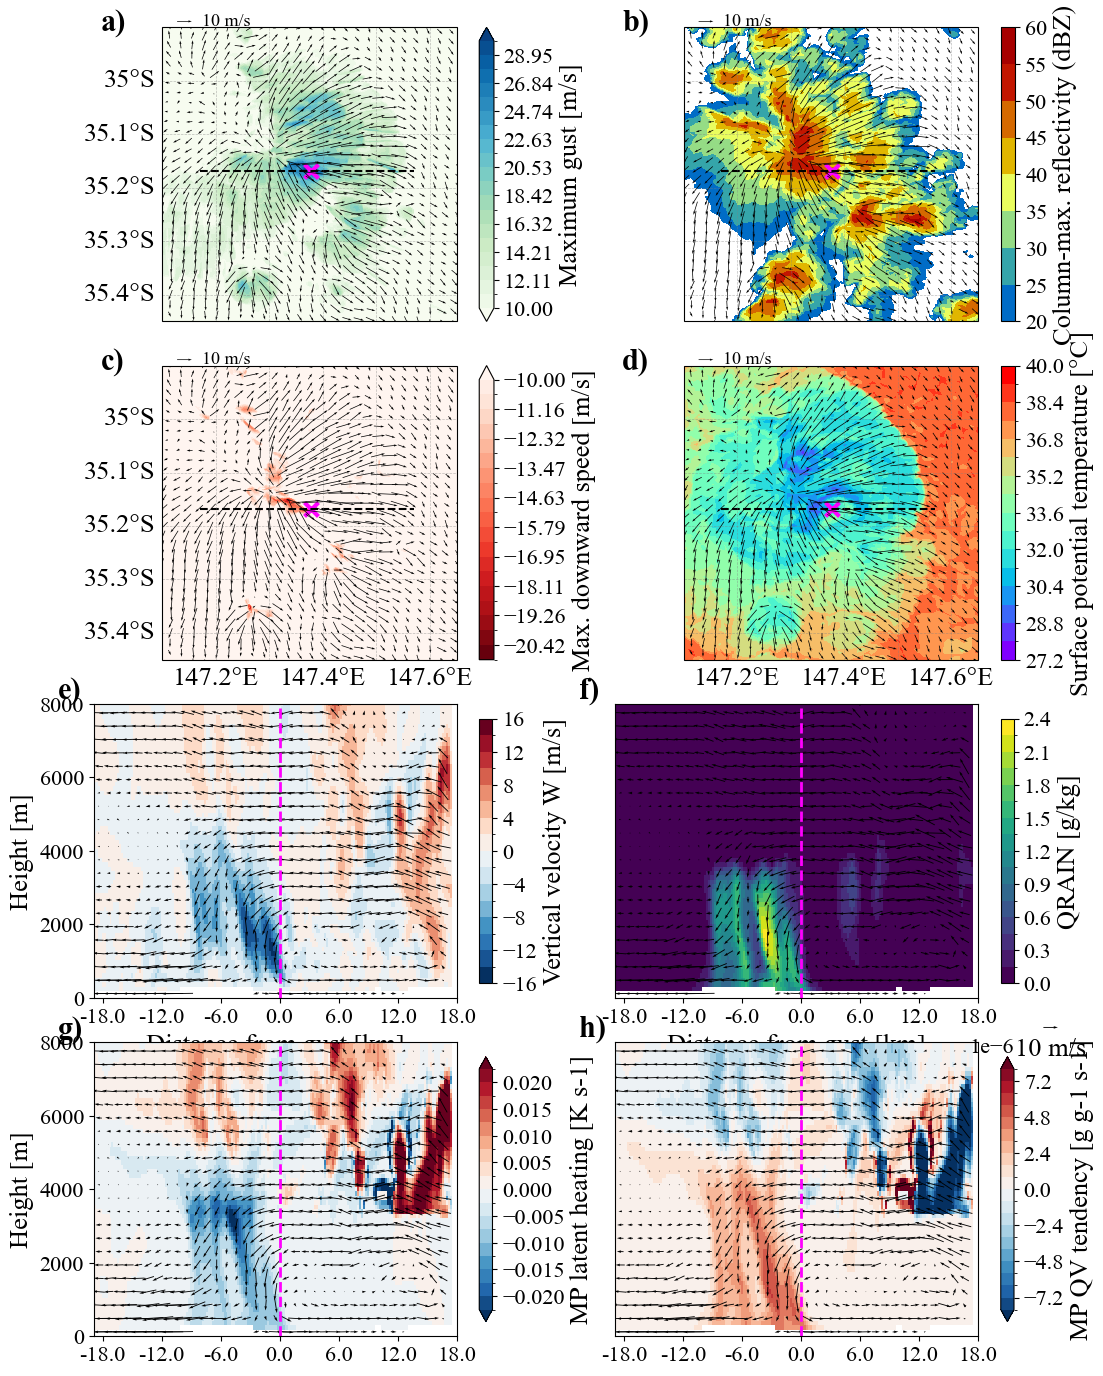

In [11]:
# Get data for Case 2 and plot maps/cross sections
case         = "CASE2_new"
dom          = "d03"
extent_plots = [147.1, 147.65, -35.45, -34.9]
vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max = get_data_cross_section(case)

plot_maps_cross_sections(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots)


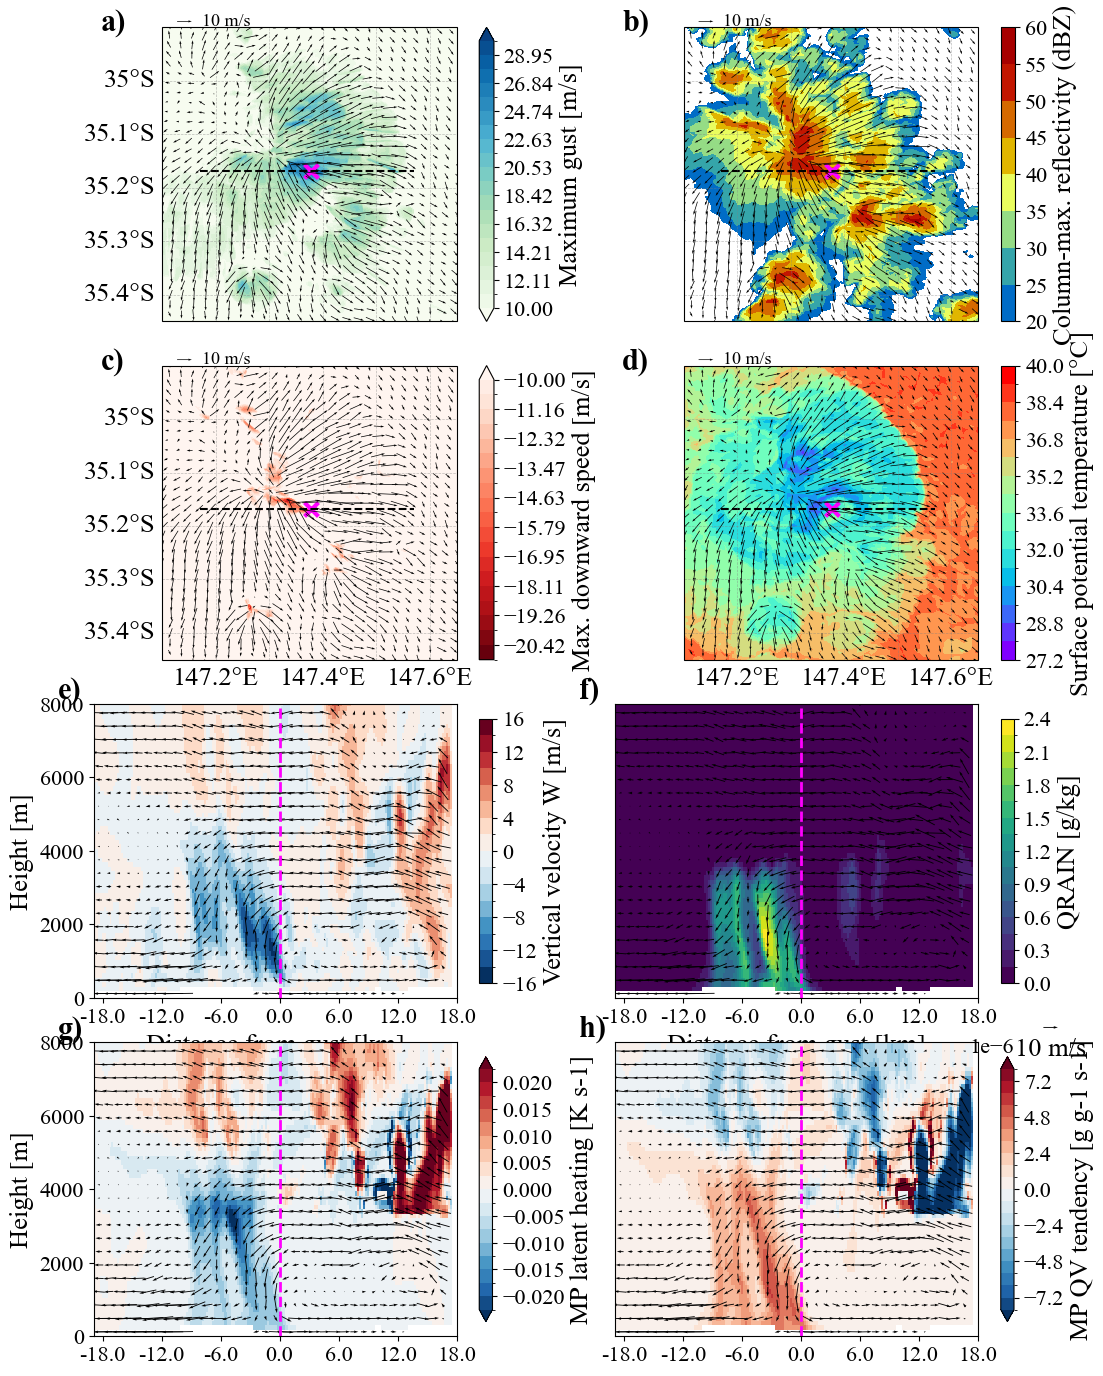

In [29]:
plot_maps_cross_sections(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots)

In [24]:
def plot_maps_cross_sections_old(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots):
    # Create figure and GridSpec with 3 rows and 2 columns
    fig = plt.figure(figsize=(13, 14))
    dom = "d03"
    fs = 19
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-3,
        "ytick.labelsize": fs-3,
        "legend.fontsize": fs-2,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })
    
    
    #gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.15, wspace=0.12)
    gs = gridspec.GridSpec(3, 2, height_ratios=[1,1,1.0], 
                           left=0.15, right=0.9,  # Control left-right margins globally
                           hspace=0.15, wspace=0.15)
    
    axes = []
    for i in range(6):
        row = i // 2
        col = i % 2
        if i < 4:
            ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        else:
            ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
        
    
    # --- Example variables ---
    lats_cross = [-35.168, -35.168]
    lons_cross = [147.17, 147.57]
    extent_plots = [147.1, 147.65, -35.45, -34.9]
    
    # --- PLOTS ---
    
    # Plot 1: Wind speed max
    plot_time(0, vars_time["WSPD10MAX"], ax=axes[0], cmap="GnBu", extent=extent_plots,
              plot_aws=False, r=15, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              vmin=10, vmax=30, levels=20,
              cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0},
             plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # Plot 2: Reflectivity
    levels = np.arange(20, 65, 5)
    ref = vars_time["REFL_10CM"].max("bottom_top").where(lambda x: x > 20.)
    plot_time(1, ref, ax=axes[1], extent=extent_plots, plot_aws=False,
              coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              cmap="HomeyerRainbow",  # Ensure pyart is imported
              vmin=20, vmax=60, levels=levels,
              cbar_kwargs={"label": "Column-max. reflectivity (dBZ)", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    # Plot 3: Downdraft speed
    plot_time(2, vars_time["W_DN_MAX"], ax=axes[2], cmap="Reds_r", extent=extent_plots,
              plot_aws=False, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              vmin=-21, vmax=-10, levels=20,
              cbar_kwargs={"label": "Max. downward speed [m/s]", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    
    
    # Plot 4: Accumulated rain
    #plot_time(3, vars_time["RAINNC"], ax=axes[3], cmap="Blues", extent=extent_plots,
    #          plot_aws=False, coords_max=coords_ws_max[dom],
    #          lats_cross=lats_cross, lons_cross=lons_cross,
    #          levels=20, vmin=0, vmax=24,
    #          cbar_kwargs={"label": "Precipitation [mm]", "shrink": 1.0})
    
    
    # Plot 4: Theta
    plot_time(3, (vars_time["theta"].isel(bottom_top = 0)-273.15), ax=axes[3], cmap="rainbow", extent=extent_plots,
              plot_aws=False, coords_max=coords_ws_max[dom],
              lats_cross=lats_cross, lons_cross=lons_cross,
              levels=20,
              cbar_kwargs={"label": "Surface potential temperature [°C]", "shrink": 1.0},
                      plot_winds = True,
             u = vars_time["U10"], 
             v = vars_time["V10"], 
             sep_w = 10, 
             scale_w = 200)
    #axes[3].coastlines(color="lightgray",lw=3)
    
    # --- Plot 5: Vertical velocity cross-section ---
    ax = axes[4]
    var = "W"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": "Vertical velocity W [m/s]",
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Plot 6: QRAIN cross-section ---
    ax = axes[5]
    var = "QRAIN"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                                cbar_kwargs={"label": f"{var} [g/kg]",
                                             "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors again
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    plt.quiverkey(q, 1.2, -0.1, 10, '10 m/s', labelpos='S', coordinates='axes')
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("")
    ax.set_yticks([])
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Label subplots (a–f) ---
    labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
    for i, ax in enumerate(axes):
        
        pos_y = 1.09 if i>=4 else 1.06
        pos_x = -0.1 if i>=4 else -0.21
        ax.text(pos_x,pos_y, labels[i], transform=ax.transAxes,
                fontsize=22, fontweight='bold', va='top', ha='left')
    
    # Get position of a reference map axis (e.g., axes[0])
    pos_ref = axes[0].get_position()
    
    # Apply the same x-position and width to the last two axes:
    for ax in axes[4:]:
        pos = ax.get_position()
        new_pos = [pos_ref.x0, pos.y0, pos_ref.width, pos.height]
        ax.set_position(new_pos)
        
    pos0 = axes[0].get_position()
    pos4 = axes[4].get_position()
    
    new_pos4 = [pos0.x0, pos4.y0, pos0.width, pos4.height]
    axes[4].set_position(new_pos4)
    
    # Adjust layout
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.08, hspace=0.25)
    plt.show()


## Figure SX: CASE2, Other variables

In [32]:
def plot_maps_cross_sections_others(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots):

    # Create figure and GridSpec with 3 rows and 2 columns
    fig = plt.figure(figsize=(13, 17))
    
    fs = 18
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-3,
        "ytick.labelsize": fs-3,
        "legend.fontsize": fs-2,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })
    
    
    #gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.15, wspace=0.12)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1,1,1., 1.], 
                           left=0.15, right=0.9,  # Control left-right margins globally
                           hspace=0.15, wspace=0.15)
    
    axes = []
    for i in range(8):
        row = i // 2
        col = i % 2
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
        
    
    # --- Example variables ---
    lats_cross = [-35.168, -35.168]
    lons_cross = [147.17, 147.57]
    extent_plots = [147.1, 147.65, -35.45, -34.9]
    
    # --- PLOTS ---
    
    # --- Plot 1: latent heating---
    ax = axes[0]
    var = "H_DIABATIC"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9}, robust = True)
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    
    # --- Plot 2: QV_DIABATIC ---
    ax = axes[1]
    var = "QV_DIABATIC"
    (vars_cross[var]).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9}, robust = True)
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    
    # --- Plot 3: QVAPOR ---
    ax = axes[2]
    var = "QVAPOR"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    
    # --- Plot 4: QCLOUD ---
    ax = axes[3]
    var = "QCLOUD"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                           cbar_kwargs={"label": names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    ax.set_yticks([])
    
    
    # --- Plot 5: QGRAUP ---
    ax = axes[4]
    var = "QGRAUP"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                           cbar_kwargs={"label":  names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    ax.set_ylabel("")
    #ax.set_yticks([])
    
    # --- Plot 6: QICE ---
    ax = axes[5]
    var = "QICE"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                           cbar_kwargs={"label":  names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    
    # --- Plot 7: QSNOW ---
    ax = axes[6]
    var = "QSNOW"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                           cbar_kwargs={"label":  names_vars[var],
                                        "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors on top
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("Height [m]")
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Plot 8: QHAIL ---
    ax = axes[7]
    var = "QHAIL"
    (vars_cross[var]*1000).plot(ax=ax, levels=20,
                                cbar_kwargs={"label": names_vars[var],
                                             "orientation": "vertical", "shrink": 0.9})
    ax.axvline(x=idx_max_cross, color="magenta", lw=2.0, ls="--")
    
    # Wind vectors again
    wind_transect = xr.Dataset({
        "uu": vars_cross["V_CROSS"],
        "w": vars_cross["W"]
    }).assign_coords({"cross_line_idx": np.arange(vars_cross["U_CROSS"].shape[1])})
    umean06 = wind_transect.sel({"vertical": slice(0, 12000)}).uu.mean()
    wind_transect["uu"] = wind_transect["uu"] - umean06
    wind_transect = wind_transect.drop_vars("xy_loc")
    wind_transect_coarsen = wind_transect.coarsen(
        dim={"cross_line_idx": 5, "vertical": 3}, boundary="trim").mean()
    q = wind_transect_coarsen.plot.quiver("cross_line_idx", "vertical", "uu", "w", scale=250, ax=ax, add_guide=False)
    plt.quiverkey(q, 1.2, -0.1, 10, '10 m/s', labelpos='S', coordinates='axes')
    ax.set_ylim([0, 8000])
    ax.set_title("")
    ax.set_ylabel("")
    ax.set_yticks([])
    # --- Distance from gust for ticks ---
    dx = 0.2  # km per grid point
    #tick_spacing = 30  # grid points
    #tick_positions = np.arange(0, vars_cross[var].shape[1], tick_spacing)
    tick_positions = np.array([4, 34, 64, 94, 124, 154, 184]) # Fixed to be centered in zero
    tick_labels = (tick_positions - idx_max_cross) * dx
    tick_labels_formatted = [f"{x:.1f}" for x in tick_labels]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels_formatted)
    ax.set_xlabel("Distance from gust [km]")
    
    # --- Label subplots (a–f) ---
    labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)']
    for i, ax in enumerate(axes):
        
        pos_y = 1.06
        ax.text(-0.1 if i in [1,3,5,7] else -0.22,pos_y, labels[i], transform=ax.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='left')
    
    # Get position of a reference map axis (e.g., axes[0])
    pos_ref = axes[0].get_position()
    
    # Apply the same x-position and width to the last two axes:
    for ax in axes[4:]:
        pos = ax.get_position()
        new_pos = [pos_ref.x0, pos.y0, pos_ref.width, pos.height]
        ax.set_position(new_pos)
        
    pos0 = axes[0].get_position()
    pos4 = axes[4].get_position()
    
    new_pos4 = [pos0.x0, pos4.y0, pos0.width, pos4.height]
    axes[4].set_position(new_pos4)
    
    # Adjust layout
    fig.subplots_adjust(wspace=0.09, hspace=0.25)
    plt.show()
    #plt.savefig()
    #plt.savefig("/g/data/up6/ai2733/FiguresPaper/FigureS2.png", dpi = 300, bbox_inches = "tight")


In [ ]:
plot_maps_cross_sections_others(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots)

## Figure SX: CASE 1

WSPD10MAX d03 read
looking for max at 15km radius from -29.49, 149.85
Max ws at d03 at 2015-12-16 07:30:00: 26.78 m/s
14
Closest index: 105


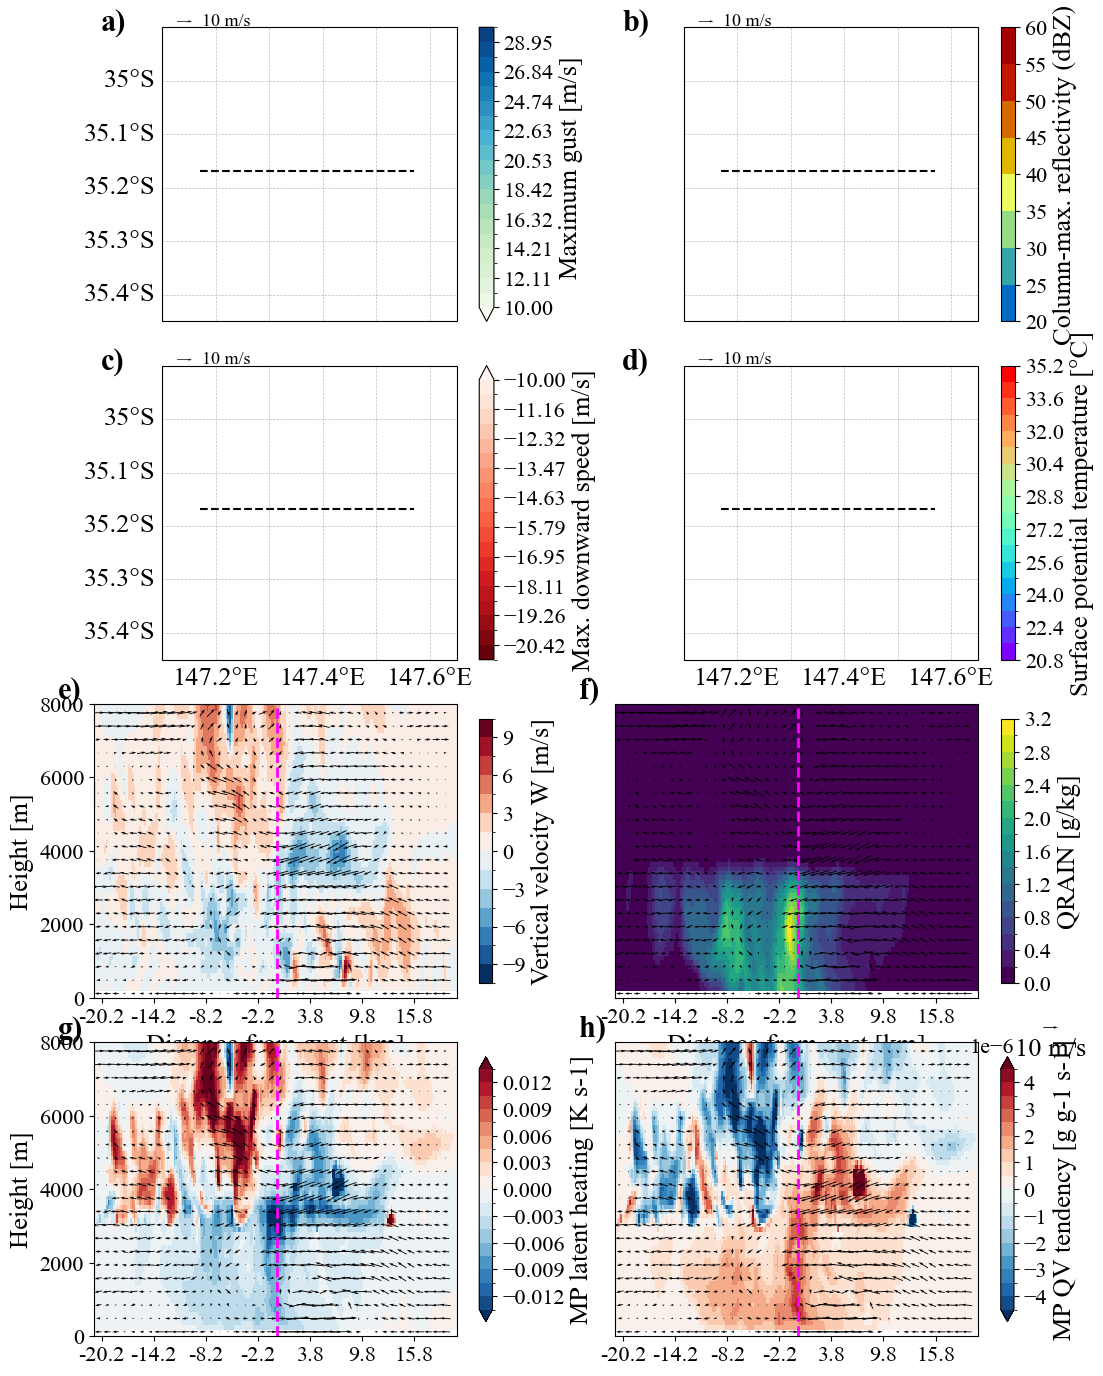

In [31]:
# Get data for Case 2
case         = "CASE1"
dom          = "d03"
extent_plots = [149.5, 150.0, -29.6, -29.15]
vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max = get_data_cross_section(case)

plot_maps_cross_sections(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots)


## Figure SX: CASE 3

WSPD10MAX d03 read
looking for max at 15km radius from -31.07, 150.84
Max ws at d03 at 2017-02-17 08:05:00: 23.71 m/s
Closest index: 98


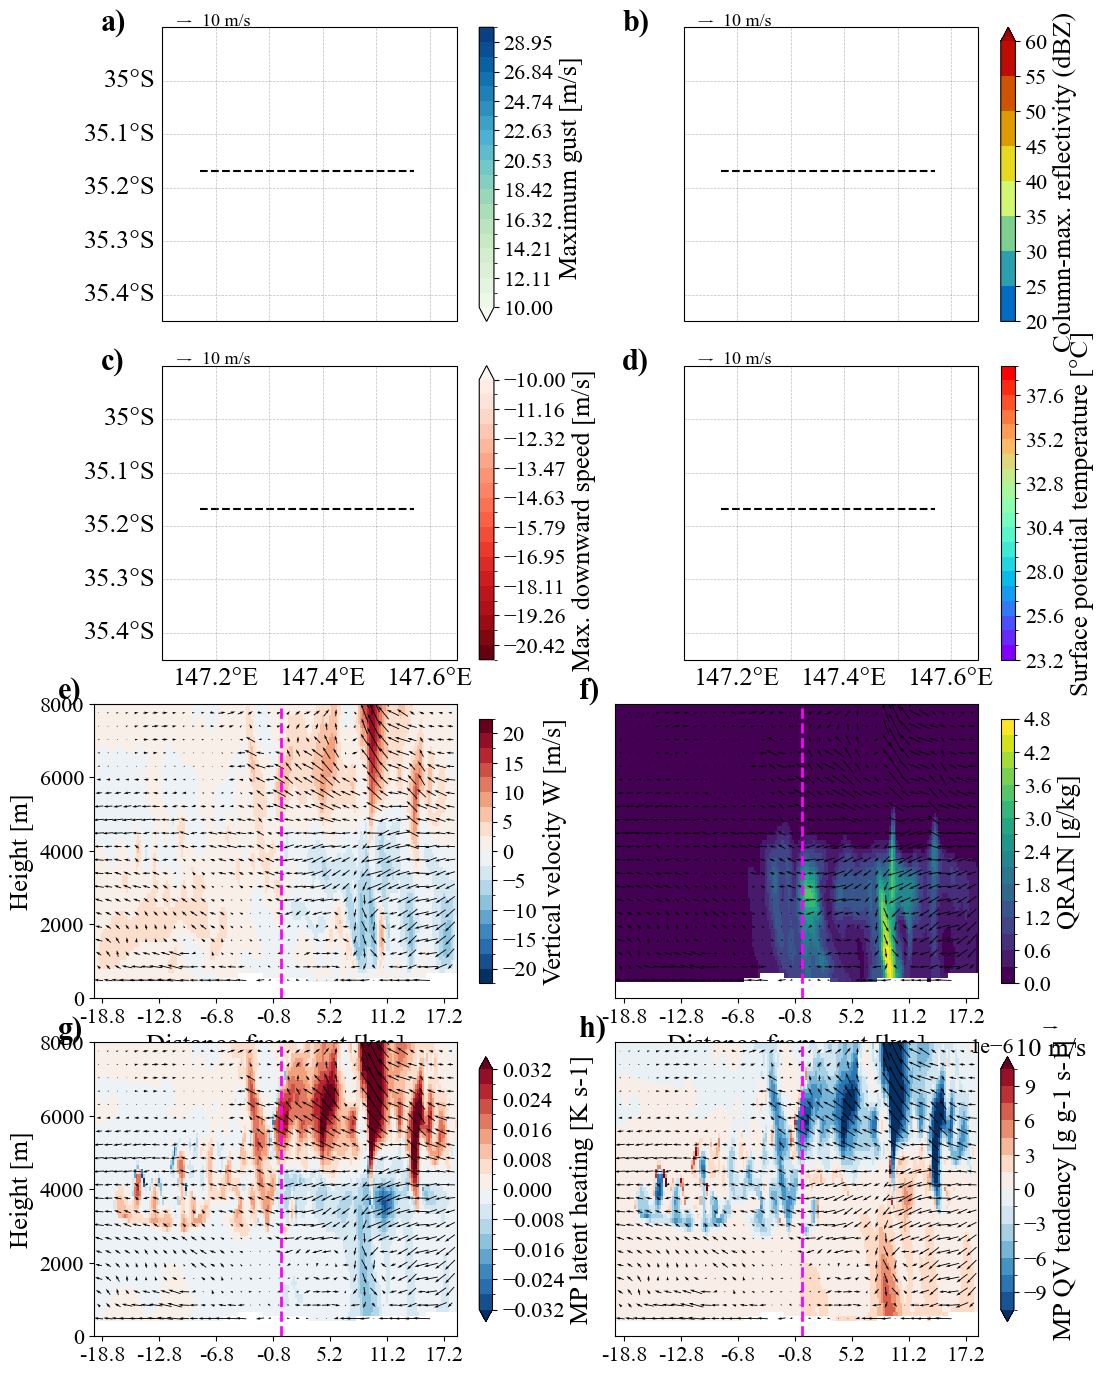

In [33]:
# Get data for Case 2
case         = "CASE3_new"
dom          = "d03"
extent_plots = [150.6, 151.3, -31.3, -30.75]
vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max = get_data_cross_section(case)

plot_maps_cross_sections(case, vars_time, vars_cross, lats_cross, lons_cross, idx_max_cross, coords_ws_max, dom, extent_plots)
